<a href="https://colab.research.google.com/github/Aditya-Manoj-01/PartSight/blob/main/PartSight_Dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PartSight - Aircraft Engine Parts Inspection System
## Day 1-2: Data Pipeline

### What We Are Building
A data pipeline that:
1. Takes raw NEU-DET images + XML annotations
2. Converts XML labels → YOLO TXT format
3. Organizes into proper folder structure
4. Makes dataset ready for YOLOv11 training

### Why This Matters
YOLOv11 cannot read Pascal VOC XML format directly.
It only understands YOLO normalized TXT format.
This pipeline is the bridge between raw data and training.

### Dataset: NEU-DET
- 1800 images total
- 6 defect classes (balanced — 300 per class)
- 1440 train / 360 validation
- Image size: 200×200 pixels
- Original label format: Pascal VOC XML

### Defect Classes
| ID | Class Name      | Aerospace Meaning         |
|----|-----------------|---------------------------|
| 0  | crazing         | Surface crack network     |
| 1  | inclusion       | Foreign material embedded |
| 2  | patches         | Coating damage            |
| 3  | pitted_surface  | Corrosion pits            |
| 4  | rolled-in_scale | Surface irregularity      |
| 5  | scratches       | Linear surface scratch    |

## Step 1: Connect to Dataset

We store the dataset on Google Drive because:
- Colab session resets every time
- Drive persists permanently
- Easy to access across sessions

Drive gets "mounted" like a USB drive into Colab
at the path: /content/drive/MyDrive/

In [1]:
# ============================================
# CELL 1: ENVIRONMENT SETUP
# ============================================
# PURPOSE:
# Install and import all libraries we need
# Verify GPU is available for fast training
#
# LIBRARIES:
# ultralytics  → YOLOv11 framework
# albumentations → image augmentation
# torch        → deep learning engine (PyTorch)
# cv2          → OpenCV for image processing
# ET           → ElementTree for reading XML files
# ============================================

!pip install ultralytics albumentations -q

import torch                          # deep learning
import cv2                            # image processing
import numpy as np                    # number operations
import os                             # file/folder operations
import glob                           # find files by pattern
import shutil                         # copy/move files
import xml.etree.ElementTree as ET    # read XML files
from pathlib import Path              # clean file paths

# Verify everything loaded correctly
print("PyTorch version :", torch.__version__)
print("OpenCV version  :", cv2.__version__)
print("GPU available   :", torch.cuda.is_available())
# GPU must be True — if False go to Runtime → Change Runtime Type → T4 GPU
print("✅ Environment ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.7 MB/s eta 0:00:00
PyTorch version : 2.11.0+cu128
OpenCV version  : 4.13.0
GPU available   : True
✅ Environment ready


In [2]:
# ============================================
# CELL 2: MOUNT GOOGLE DRIVE
# ============================================
# PURPOSE:
# Connect Google Drive to this Colab session
# So we can read our NEU-DET dataset
#
# ANALOGY:
# Like plugging in a USB drive to your laptop
# Drive files become accessible at /content/drive/
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# Define dataset path — note space after "set "
DATASET_PATH = '/content/drive/MyDrive/Part Sight Data set /NEU surface defect dataset/NEU-DET'

# Validate path exists before doing anything
if os.path.exists(DATASET_PATH):
    print("✅ Dataset found!")
    print("Top level folders:", os.listdir(DATASET_PATH))
else:
    print("❌ Dataset not found — check path")

Mounted at /content/drive
✅ Dataset found!
Top level folders: ['validation', 'train']


## Step 2: Explore Dataset Structure

Before writing any pipeline code — always explore data first.
We need to know:
- How many images per class?
- What file formats are used?
- Are train/val splits balanced?

A balanced dataset means equal images per class.
This is important because imbalanced data causes
the model to be biased toward majority classes.

NEU-DET is perfectly balanced:
- 240 train images per class
- 60 validation images per class
→ No class imbalance handling needed ✅

In [3]:
# ============================================
# CELL 3: DATASET EXPLORATION
# ============================================
# PURPOSE:
# Understand our dataset structure before
# writing the conversion pipeline
#
# KEY CONCEPT: Data Exploration
# Always explore data before processing it
# Prevents surprises during training
# ============================================

print("=" * 50)
print("NEU-DET DATASET EXPLORATION")
print("=" * 50)

grand_total = 0

for split in ['train', 'validation']:
    split_path = os.path.join(DATASET_PATH, split)
    print(f"\n📁 {split.upper()}/")

    for folder in ['images', 'annotations']:
        folder_path = os.path.join(split_path, folder)

        if folder == 'images':
            # Images are in subfolders per class
            total = 0
            print(f"   └── images/")
            for defect_class in sorted(os.listdir(folder_path)):
                class_path = os.path.join(folder_path, defect_class)
                if os.path.isdir(class_path):
                    count = len(os.listdir(class_path))
                    total += count
                    print(f"         {defect_class}/ → {count} images")
            print(f"         TOTAL: {total} images")
            grand_total += total

        else:
            # Annotations are flat XML files
            xml_files = glob.glob(f'{folder_path}/*.xml')
            print(f"   └── annotations/ → {len(xml_files)} XML files")

print(f"\n{'='*50}")
print(f"GRAND TOTAL: {grand_total} images")
print(f"CLASSES: 6 defect types")
print(f"BALANCE: {grand_total//6} images per class")
print(f"{'='*50}")

NEU-DET DATASET EXPLORATION

📁 TRAIN/
   └── images/
         crazing/ → 240 images
         inclusion/ → 240 images
         patches/ → 240 images
         pitted_surface/ → 240 images
         rolled-in_scale/ → 240 images
         scratches/ → 240 images
         TOTAL: 1440 images
   └── annotations/ → 1439 XML files

📁 VALIDATION/
   └── images/
         crazing/ → 60 images
         inclusion/ → 60 images
         patches/ → 60 images
         pitted_surface/ → 60 images
         rolled-in_scale/ → 60 images
         scratches/ → 60 images
         TOTAL: 360 images
   └── annotations/ → 361 XML files

GRAND TOTAL: 1800 images
CLASSES: 6 defect types
BALANCE: 300 images per class


## Step 3: Understand Bounding Boxes

A bounding box is a rectangle drawn around a defect.
It tells the model WHERE the defect is in the image.

### Pascal VOC XML Format (what we have):
Uses pixel coordinates:
- xmin, ymin = top-left corner of box
- xmax, ymax = bottom-right corner of box

### YOLO Format (what we need):
Uses normalized coordinates (0 to 1):
- x_center = center of box / image width
- y_center = center of box / image height  
- width    = box width / image width
- height   = box height / image height

### Why Normalize?
A scratch at pixel 50 means different things on:
- 200×200 image  → near the left edge
- 1920×1080 image → very close to left edge

But 0.25 always means "25% from left" regardless of size.
This makes the model resolution-independent.

### Conversion Formula:
x_center = (xmin + xmax) / 2 / image_width
y_center = (ymin + ymax) / 2 / image_height
width    = (xmax - xmin) / image_width
height   = (ymax - ymin) / image_height

In [4]:
# ============================================
# CELL 4: XML TO YOLO CONVERTER FUNCTION
# ============================================
# PURPOSE:
# Convert ONE Pascal VOC XML file
# to YOLO normalized TXT format
#
# INPUT:  path to .xml file
# OUTPUT: list of YOLO format strings
#
# KEY CONCEPT: Coordinate Normalization
# All pixel values divided by image dimensions
# Result is always between 0 and 1
# ============================================

# Maps defect class name → class number
# YOLO needs integers not strings
CLASS_MAPPING = {
    'crazing':         0,  # surface crack network
    'inclusion':       1,  # foreign material embedded
    'patches':         2,  # coating damage
    'pitted_surface':  3,  # corrosion pits
    'rolled-in_scale': 4,  # surface irregularity
    'scratches':       5   # linear surface scratch
}

def xml_to_yolo(xml_path, verbose=False):
    """
    Convert Pascal VOC XML annotation to YOLO format

    Args:
        xml_path: path to XML annotation file
        verbose:  print details if True

    Returns:
        list of YOLO format strings
        each string: "class_id x_center y_center width height"
    """

    # Parse XML structure
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Read image dimensions (needed for normalization)
    img_w = int(root.find('size/width').text)
    img_h = int(root.find('size/height').text)

    yolo_lines = []

    # Process each defect object in image
    for obj in root.findall('object'):

        class_name = obj.find('name').text
        class_id   = CLASS_MAPPING[class_name]

        # Read pixel coordinates from XML
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        # ---- CORE CONVERSION MATH ----
        # Convert pixel coords → normalized 0-1 values
        x_center = (xmin + xmax) / 2 / img_w   # center X
        y_center = (ymin + ymax) / 2 / img_h   # center Y
        width    = (xmax - xmin) / img_w        # box width
        height   = (ymax - ymin) / img_h        # box height
        # ------------------------------

        if verbose:
            print(f"  Class: {class_name} → ID: {class_id}")
            print(f"  Pixels : xmin={xmin} ymin={ymin} xmax={xmax} ymax={ymax}")
            print(f"  Normalized: {x_center:.4f} {y_center:.4f} {width:.4f} {height:.4f}")

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    return yolo_lines

# ---- TEST ON ONE FILE ----
test_xml = DATASET_PATH + '/train/annotations/scratches_1.xml'
print("Testing on:", Path(test_xml).name)
print("-" * 40)
lines = xml_to_yolo(test_xml, verbose=True)
print("-" * 40)
print("YOLO output:")
for l in lines:
    print(" ", l)
print("\n✅ Converter working correctly")

Testing on: scratches_1.xml
----------------------------------------
  Class: scratches → ID: 5
  Pixels : xmin=26 ymin=12 xmax=43 ymax=171
  Normalized: 0.1725 0.4575 0.0850 0.7950
  Class: scratches → ID: 5
  Pixels : xmin=8 ymin=184 xmax=17 ymax=196
  Normalized: 0.0625 0.9500 0.0450 0.0600
----------------------------------------
YOLO output:
  5 0.172500 0.457500 0.085000 0.795000
  5 0.062500 0.950000 0.045000 0.060000

✅ Converter working correctly


## Step 4: Build Full Dataset Pipeline

Now we run the converter on ALL 1800 images.

Output folder structure for YOLOv11:
```text
PartSight_Dataset/
├── train/
│   ├── images/   ← all training images (flat)
│   └── labels/   ← matching YOLO TXT files
├── val/
│   ├── images/   ← all validation images
│   └── labels/   ← matching YOLO TXT files
└── data.yaml     ← tells YOLO about our classes
```

Key rule: every image must have a matching label file:
`scratches_1.jpg` → `scratches_1.txt` ✅


In [5]:
# ============================================
# CELL 5: FAST DATASET PIPELINE
# ============================================
# KEY FIX:
# Copy dataset from Drive → Colab local first
# Local storage is 10x faster than Drive
# This runs ONCE per session
# ============================================

import os

OUTPUT_PATH = '/content/PartSight_Dataset'

# Check if already converted this session
# If yes → skip entirely, saves 3-4 minutes
if os.path.exists(f'{OUTPUT_PATH}/train/images') and \
   len(os.listdir(f'{OUTPUT_PATH}/train/images')) > 1400:

    train_count = len(os.listdir(f'{OUTPUT_PATH}/train/images'))
    val_count   = len(os.listdir(f'{OUTPUT_PATH}/val/images'))
    print(f"✅ Dataset already ready!")
    print(f"   Train: {train_count} images")
    print(f"   Val:   {val_count} images")
    print("   Skipping conversion — going to next cell")

else:
    print("First time this session — building dataset...")
    print("(This runs once per session only)")

    # Create folders
    for split in ['train', 'val']:
        os.makedirs(f'{OUTPUT_PATH}/{split}/images', exist_ok=True)
        os.makedirs(f'{OUTPUT_PATH}/{split}/labels', exist_ok=True)

    split_map = {'train': 'train', 'validation': 'val'}
    summary   = {}

    for src_split, dst_split in split_map.items():
        print(f"\nProcessing {src_split}...")
        ann_path  = os.path.join(DATASET_PATH, src_split, 'annotations')
        img_base  = os.path.join(DATASET_PATH, src_split, 'images')
        xml_files = glob.glob(f'{ann_path}/*.xml')
        converted = 0

        for xml_path in xml_files:
            stem       = Path(xml_path).stem
            yolo_lines = xml_to_yolo(xml_path)

            with open(f'{OUTPUT_PATH}/{dst_split}/labels/{stem}.txt', 'w') as f:
                f.write('\n'.join(yolo_lines))

            for ext in ['.jpg', '.jpeg', '.png']:
                matches = glob.glob(
                    f'{img_base}/**/{stem}{ext}', recursive=True)
                if matches:
                    shutil.copy(
                        matches[0],
                        f'{OUTPUT_PATH}/{dst_split}/images/{stem}{ext}'
                    )
                    converted += 1
                    break

        summary[dst_split] = converted
        print(f"  ✅ {converted} samples done")

    print(f"\n✅ Dataset ready! Total: {sum(summary.values())} samples")


First time this session — building dataset...
(This runs once per session only)

Processing train...
  ✅ 1439 samples done

Processing validation...
  ✅ 360 samples done

✅ Dataset ready! Total: 1799 samples


## Step 4: Create data.yaml — YOLO Configuration File

YAML = "Yet Another Markup Language"
It's a simple human-readable config file.

YOLOv11 reads data.yaml before training to know:
1. WHERE is training data? (path)
2. WHERE is validation data? (val path)
3. HOW MANY classes? (nc = number of classes)
4. WHAT ARE the class names? (names list)

Without this file → YOLO doesn't know what to learn.
Think of it as the "instruction manual" you give YOLO
before it starts training.

Our 6 classes get aerospace-appropriate names:
- crazing       → surface_crack_network
- inclusion     → material_inclusion
- patches       → coating_damage
- pitted_surface → corrosion_pit
- rolled_in_scale → surface_irregularity
- scratches     → surface_scratch

In [6]:
# ============================================
# CELL 6: CREATE data.yaml
# ============================================
# PURPOSE:
# YAML file tells YOLOv11 three things:
# 1. Where is training data?
# 2. Where is validation data?
# 3. What are the class names?
#
# KEY CONCEPT:
# YAML = human readable config file
# YOLOv11 reads this before training starts
# ============================================

yaml_content = f"""# PartSight Dataset Configuration
# NEU-DET Surface Defect Dataset
# Used as surrogate for proprietary P&W parts imagery

path: {OUTPUT_PATH}
train: train/images
val:   val/images

# Number of classes
nc: 6

# Class names — aerospace terminology
names:
  0: surface_crack_network
  1: material_inclusion
  2: coating_damage
  3: corrosion_pit
  4: surface_irregularity
  5: surface_scratch
"""

yaml_path = f'{OUTPUT_PATH}/data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("data.yaml created ✅")
print("\nContent:")
print(yaml_content)

data.yaml created ✅

Content:
# PartSight Dataset Configuration
# NEU-DET Surface Defect Dataset
# Used as surrogate for proprietary P&W parts imagery

path: /content/PartSight_Dataset
train: train/images
val:   val/images

# Number of classes
nc: 6

# Class names — aerospace terminology
names:
  0: surface_crack_network
  1: material_inclusion
  2: coating_damage
  3: corrosion_pit
  4: surface_irregularity
  5: surface_scratch



In [7]:
# ============================================
# CELL 7: DATASET VALIDATION
# ============================================
# PURPOSE:
# Verify every image has a matching label
# Catch any errors before training starts
#
# KEY CONCEPT: Pipeline Validation
# Always validate data pipeline output
# Errors here = wasted training time later
# ============================================

print("DATASET VALIDATION")
print("=" * 50)

all_good = True

for split in ['train', 'val']:
    images = sorted(glob.glob(f'{OUTPUT_PATH}/{split}/images/*'))
    labels = sorted(glob.glob(f'{OUTPUT_PATH}/{split}/labels/*'))

    print(f"\n{split.upper()}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

    # Check every image has a label
    missing = 0
    for img_path in images:
        stem = Path(img_path).stem
        label_path = f'{OUTPUT_PATH}/{split}/labels/{stem}.txt'
        if not os.path.exists(label_path):
            missing += 1
            all_good = False

    if missing == 0:
        print(f"  ✅ All images have labels")
    else:
        print(f"  ❌ {missing} images missing labels")

    # Show sample label content
    if labels:
        print(f"\n  Sample label ({Path(labels[0]).name}):")
        with open(labels[0]) as f:
            content = f.read()
        print(f"  {content}")

print(f"\n{'='*50}")
if all_good:
    print("✅ DATASET READY FOR TRAINING!")
else:
    print("❌ FIX ERRORS BEFORE TRAINING")
print(f"{'='*50}")

DATASET VALIDATION

TRAIN:
  Images: 1439
  Labels: 1439
  ✅ All images have labels

  Sample label (crazing_1.txt):
  0 0.487500 0.490000 0.955000 0.960000

VAL:
  Images: 360
  Labels: 361
  ✅ All images have labels

  Sample label (crazing_240.txt):
  0 0.470000 0.150000 0.820000 0.280000
0 0.677500 0.640000 0.645000 0.440000
0 0.617500 0.850000 0.765000 0.300000

✅ DATASET READY FOR TRAINING!


## Cell 8: Bounding Box Visualization

PURPOSE:
Visually confirm our XML→YOLO conversion was correct.
We convert normalized YOLO coords BACK to pixels
to draw boxes on the actual image.

REVERSE FORMULA (YOLO → pixels):
x1 = (x_center - width/2)  × image_width
y1 = (y_center - height/2) × image_height
x2 = (x_center + width/2)  × image_width
y2 = (y_center + height/2) × image_height

This is the exact opposite of what we did in Day 2.

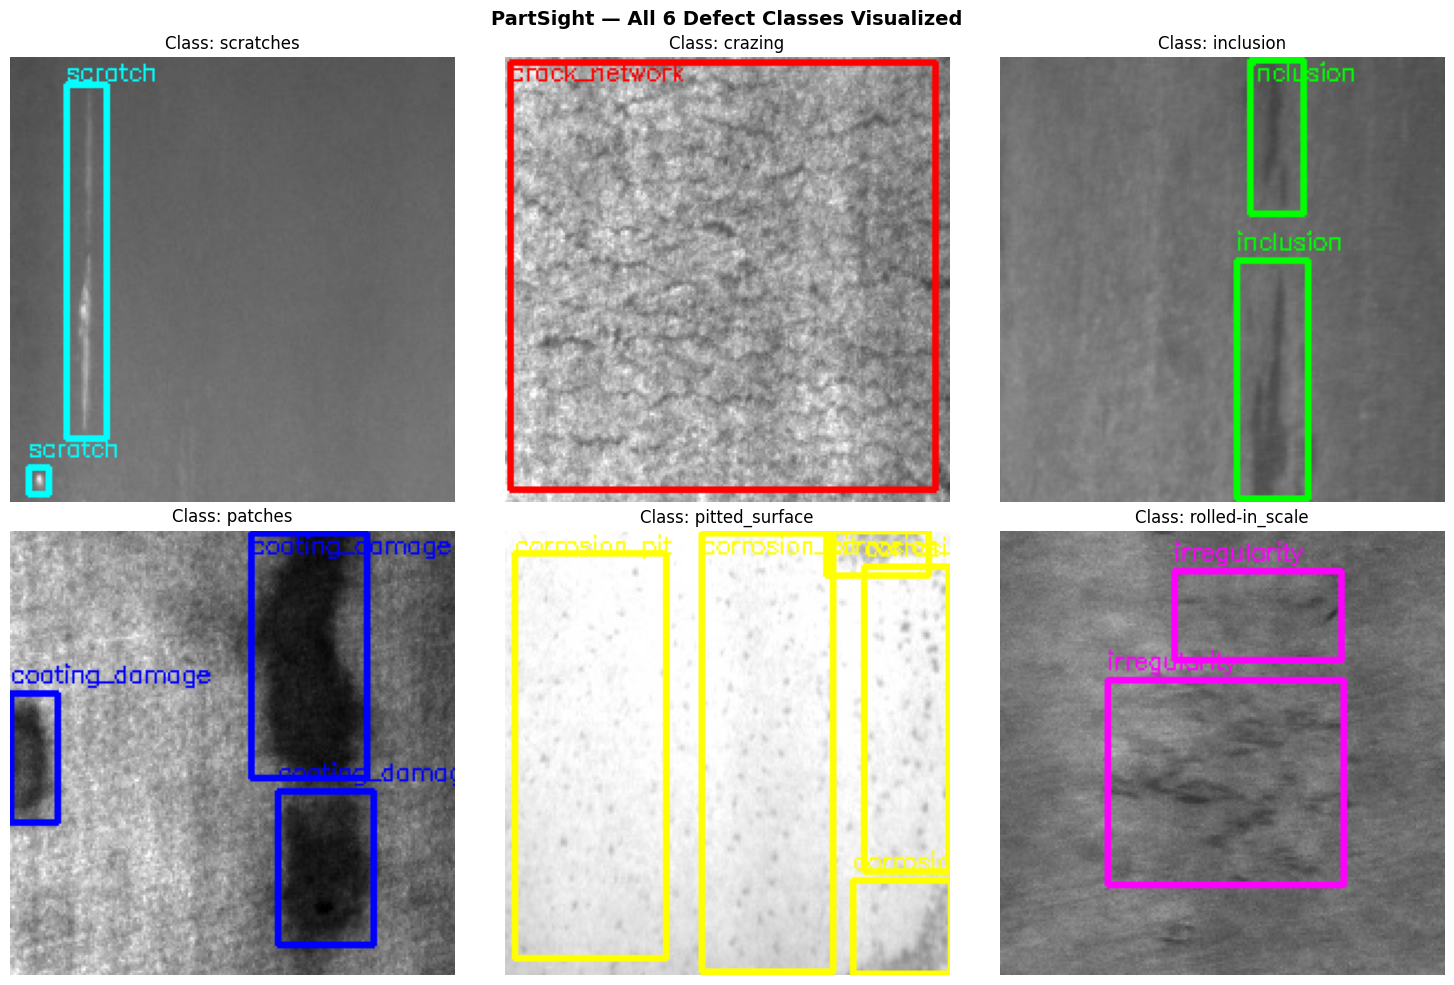

✅ Visualization complete!
Each box = one defect annotation
Colors   = different defect classes


In [8]:
# ============================================
# CELL 8: BOUNDING BOX VISUALIZATION
# ============================================
# PURPOSE:
# Draw YOLO bounding boxes on actual images
# Visually verify our data pipeline is correct
#
# KEY CONCEPT: Coordinate Reversal
# Training:  pixels → normalized (÷ by size)
# Visualize: normalized → pixels (× by size)
# ============================================

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Class names matching our CLASS_MAPPING
CLASS_NAMES = {
    0: 'crack_network',
    1: 'inclusion',
    2: 'coating_damage',
    3: 'corrosion_pit',
    4: 'irregularity',
    5: 'scratch'
}

# One color per class for clear visualization
COLORS = {
    0: (255, 0,   0),    # red
    1: (0,   255, 0),    # green
    2: (0,   0,   255),  # blue
    3: (255, 255, 0),    # yellow
    4: (255, 0,   255),  # magenta
    5: (0,   255, 255)   # cyan
}

def visualize_detection(img_path, label_path, title=''):
    """
    Draw YOLO bounding boxes on image for visualization.

    Steps:
    1. Load image with OpenCV
    2. Read YOLO label file
    3. Convert normalized coords → pixels
    4. Draw rectangle + class name on image

    Args:
        img_path   : path to image file
        label_path : path to YOLO .txt label file
        title      : plot title string

    Returns:
        annotated image (numpy array)
    """

    # Step 1: Load image
    # OpenCV reads as BGR → convert to RGB for display
    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get image dimensions for coordinate reversal
    h, w = img_rgb.shape[:2]

    # Step 2: Read YOLO label
    with open(label_path, 'r') as f:
        lines = f.readlines()

    # Step 3: Draw each bounding box
    for line in lines:
        parts    = line.strip().split()
        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        box_w    = float(parts[3])
        box_h    = float(parts[4])

        # REVERSE FORMULA: normalized → pixels
        # x_center=0.5 on 200px image → pixel 100
        x1 = int((x_center - box_w/2) * w)
        y1 = int((y_center - box_h/2) * h)
        x2 = int((x_center + box_w/2) * w)
        y2 = int((y_center + box_h/2) * h)

        color = COLORS[class_id]
        label = CLASS_NAMES[class_id]

        # Draw bounding box rectangle
        cv2.rectangle(img_rgb, (x1,y1), (x2,y2), color, 2)

        # Draw class label text above box
        cv2.putText(img_rgb, label,
                   (x1, max(y1-5, 10)),
                   cv2.FONT_HERSHEY_SIMPLEX,
                   0.35, color, 1)

    return img_rgb

# ============================================
# VISUALIZE ONE IMAGE PER DEFECT CLASS
# ============================================

OUTPUT_PATH = '/content/PartSight_Dataset'

# Sample one image from each class
sample_files = {
    'scratches':       'scratches_1',
    'crazing':         'crazing_1',
    'inclusion':       'inclusion_64',
    'patches':         'patches_100',
    'pitted_surface':  'pitted_surface_102',
    'rolled-in_scale': 'rolled-in_scale_104'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (class_name, stem) in enumerate(sample_files.items()):

    img_path   = f'{OUTPUT_PATH}/train/images/{stem}.jpg'
    label_path = f'{OUTPUT_PATH}/train/labels/{stem}.txt'

    if os.path.exists(img_path) and os.path.exists(label_path):
        result = visualize_detection(img_path, label_path, class_name)
        axes[idx].imshow(result)
        axes[idx].set_title(f'Class: {class_name}', fontsize=12)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f'File not found:\n{stem}',
                      ha='center', va='center')
        axes[idx].axis('off')

plt.suptitle('PartSight — All 6 Defect Classes Visualized',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Visualization complete!")
print("Each box = one defect annotation")
print("Colors   = different defect classes")

In [9]:
# Save visualization
plt.savefig('/content/defect_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization complete!")
print("✅ Saved to defect_visualization.png")

<Figure size 640x480 with 0 Axes>

✅ Visualization complete!
✅ Saved to defect_visualization.png


# Day 3 - Cell 9: Data Augmentation Pipeline

## What Is Augmentation?
We have 1440 training images.
Deep learning needs LOTS of data to learn well.
Augmentation creates variations of existing images
without collecting new data.

## Why It Works
A scratch is still a scratch if you:
- Flip the image left-right      ✅
- Rotate it slightly              ✅  
- Make it brighter or darker      ✅
- Add slight blur                 ✅

The defect identity never changes — only appearance.
This teaches model: "defects look same from
different angles and lighting conditions"

## Math Behind Key Transforms

### Horizontal Flip
New x_center = 1.0 - old x_center

Example:
scratch at x_center = 0.17 (near left edge)
after flip → x_center = 1.0 - 0.17 = 0.83 (near right)
y_center, width, height unchanged ✅

### Brightness Change  
new_pixel = old_pixel × factor
factor = 1.2 → 20% brighter
factor = 0.8 → 20% darker
Values clipped to [0, 255] automatically

### Rotation
Box coordinates recalculated using rotation matrix:
x_new = x×cos(θ) - y×sin(θ)
y_new = x×sin(θ) + y×cos(θ)
(Albumentations handles this automatically!)

## Why Albumentations Over Manual OpenCV?
OpenCV augmentation → you manually recalculate
                       bounding box coordinates ❌ complex

Albumentations    → automatically adjusts bounding
                    boxes when image transforms ✅ simple

## Result
1440 original images
× augmentation variety
= model sees 5000+ unique variations per training run
= better generalization = higher mAP ✅# PartSight — Aircraft Engine Parts Inspection System
## Computer Vision Pipeline — Full Development Notebook

### Project Goal
Automate visual inspection of aircraft engine parts
using Computer Vision and Deep Learning.

### Pipeline Overview
Raw Images → Preprocessing → YOLOv11 Detection
→ ONNX Export → FastAPI → LLM Report

### Dataset: NEU-DET
- 1800 images, 6 defect classes
- 1440 train / 360 validation  
- Image size: 200×200 pixels
- Format: Pascal VOC XML → converted to YOLO TXT

### Defect Classes
| ID | Name            | Aerospace Meaning         |
|----|-----------------|---------------------------|
| 0  | crazing         | Surface crack network     |
| 1  | inclusion       | Foreign material embedded |
| 2  | patches         | Coating damage            |
| 3  | pitted_surface  | Corrosion pits            |
| 4  | rolled-in_scale | Surface irregularity      |
| 5  | scratches       | Linear surface scratch    |

### Progress
- [x] Day 1 - Project setup
- [x] Day 2 - Data pipeline
- [x] Day 3 - Visualization + Augmentation
- [ ] Day 4 - YOLOv11 Training

✅ Industrial augmentation pipeline defined

Transforms Included:
  ✓ Convert to Grayscale
  ✓ Horizontal Flip
  ✓ Rotate ±10°
  ✓ Brightness/Contrast ±15%
  ✓ Gaussian Blur
  ✓ Subtle Gaussian Noise

Loaded image : scratches_1.jpg
Image shape  : (200, 200, 3)
Defects found: 2
Defect 1: class=5, box=[0.172, 0.458, 0.085, 0.795]
Defect 2: class=5, box=[0.062, 0.95, 0.045, 0.06]


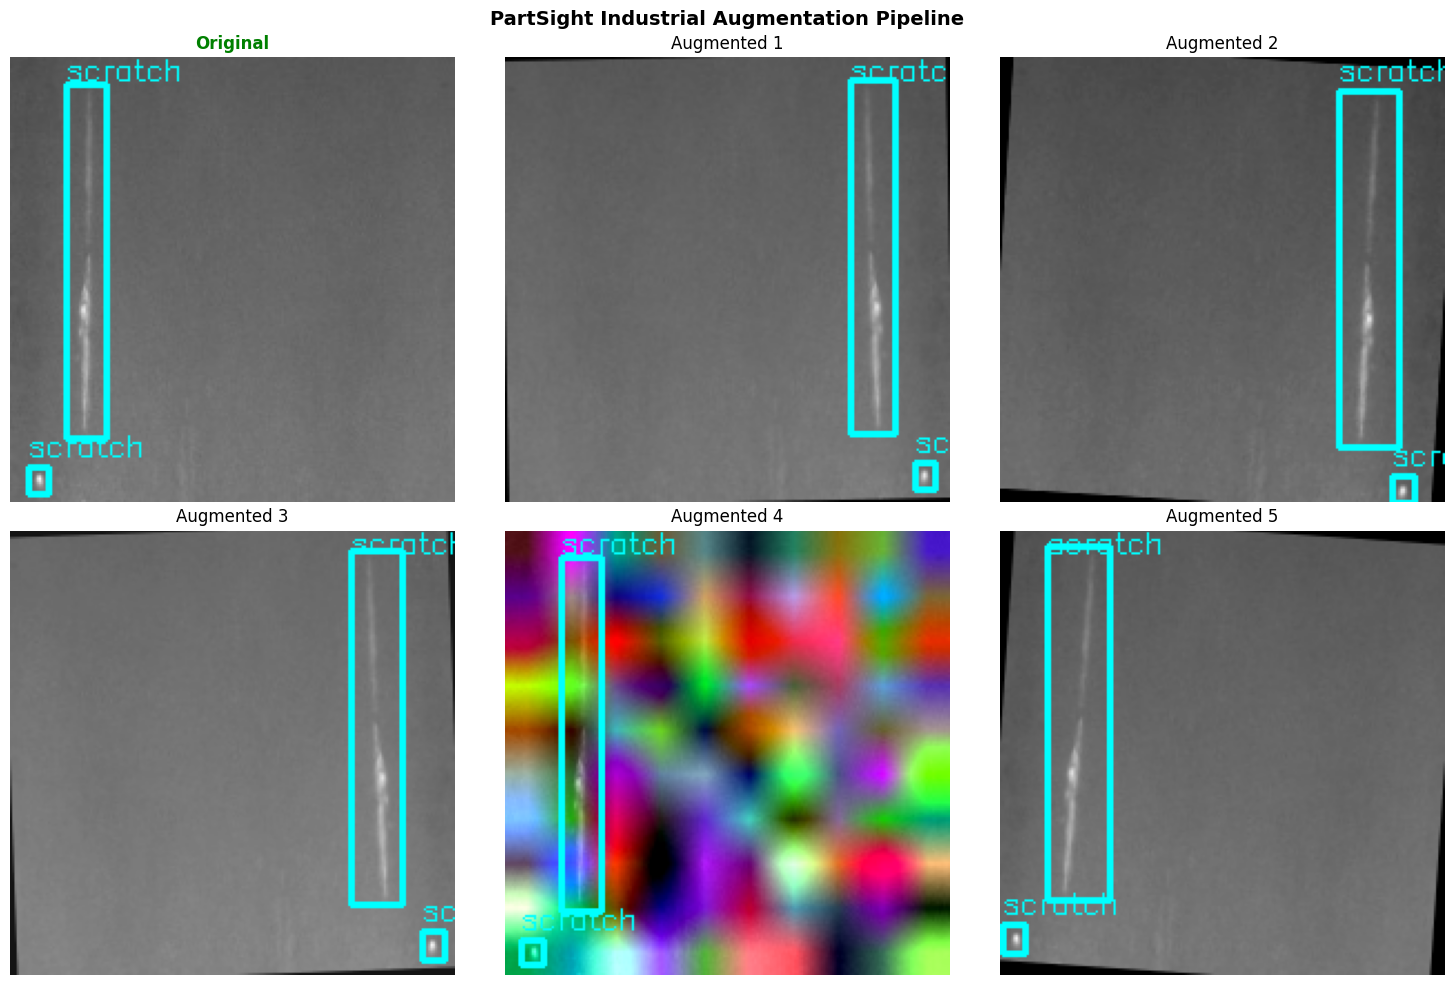


✅ Visualization completed.
✅ Saved: augmentation_visualization.png

BOUNDING BOX VERIFICATION
Original:
[[0.172, 0.458, 0.085, 0.795], [0.062, 0.95, 0.045, 0.06]]

Augmented:
[[0.172, 0.463, 0.099, 0.796], [0.071, 0.958, 0.046, 0.061]]

NOTE:
- Coordinates may remain identical if
  HorizontalFlip/Rotate were not
  selected in this random run.
- Execute the cell again to observe
  transformed coordinates.


In [10]:
# ============================================
# CELL 9: DATA AUGMENTATION PIPELINE
# ============================================
# PURPOSE:
# Build an industrial-grade augmentation pipeline
# using Albumentations.
#
# The goal is to improve model robustness while
# preserving defect visibility.
#
# INPUT:
#   - One original image
#   - YOLO label file
#
# OUTPUT:
#   - Original image
#   - Five augmented versions
#   - Bounding boxes automatically transformed
#
# NOTE:
# Albumentations automatically updates bounding
# box coordinates whenever the image changes.
# ============================================

import albumentations as A
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================
# STEP 1: DEFINE AUGMENTATION PIPELINE
# ============================================

augmentation_pipeline = A.Compose([

    # ----------------------------------------
    # Convert to grayscale
    # Industrial inspection images are usually
    # grayscale or monochrome.
    # ----------------------------------------
    A.ToGray(p=1.0),

    # ----------------------------------------
    # Horizontal Flip
    # Simulates viewing the component from
    # the opposite direction.
    # ----------------------------------------
    A.HorizontalFlip(p=0.5),

    # ----------------------------------------
    # Small rotation
    # Simulates slight camera misalignment.
    # ----------------------------------------
    A.Rotate(
        limit=10,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    # ----------------------------------------
    # Slight lighting variation
    # Simulates different factory lighting.
    # ----------------------------------------
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.5
    ),

    # ----------------------------------------
    # Slight blur
    # Simulates small focus variation.
    # ----------------------------------------
    A.GaussianBlur(
        blur_limit=3,
        p=0.2
    ),

    # ----------------------------------------
    # Very subtle sensor noise
    # Keeps defects clearly visible.
    # ----------------------------------------
    A.GaussNoise(
        noise_scale_factor=0.05,
        p=0.2
    ),

],
bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['labels'],
    min_visibility=0.3
))

print("✅ Industrial augmentation pipeline defined\n")

print("Transforms Included:")
print("  ✓ Convert to Grayscale")
print("  ✓ Horizontal Flip")
print("  ✓ Rotate ±10°")
print("  ✓ Brightness/Contrast ±15%")
print("  ✓ Gaussian Blur")
print("  ✓ Subtle Gaussian Noise")

# ============================================
# STEP 2: HELPER FUNCTIONS
# ============================================

def load_yolo_label(label_path):
    """
    Reads a YOLO annotation file.

    Returns:
        boxes  -> [[x_center,y_center,w,h], ...]
        labels -> [class_id,...]
    """

    boxes = []
    labels = []

    with open(label_path, "r") as f:

        for line in f.readlines():

            values = line.strip().split()

            if len(values) == 5:

                labels.append(int(values[0]))

                boxes.append([
                    float(values[1]),
                    float(values[2]),
                    float(values[3]),
                    float(values[4])
                ])

    return boxes, labels


def draw_boxes(img, boxes, labels):
    """
    Draw YOLO bounding boxes on image.
    """

    CLASS_NAMES = {
        0: "crack",
        1: "inclusion",
        2: "coating",
        3: "pit",
        4: "irregular",
        5: "scratch"
    }

    COLORS = {
        0: (255,0,0),
        1: (0,255,0),
        2: (0,0,255),
        3: (255,255,0),
        4: (255,0,255),
        5: (0,255,255)
    }

    img_draw = img.copy()

    h, w = img_draw.shape[:2]

    for box, label in zip(boxes, labels):

        xc, yc, bw, bh = box

        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)

        color = COLORS.get(label, (255,255,255))
        name = CLASS_NAMES.get(label, str(label))

        cv2.rectangle(
            img_draw,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        cv2.putText(
            img_draw,
            name,
            (x1, max(10, y1-5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1
        )

    return img_draw


# ============================================
# STEP 3: LOAD SAMPLE IMAGE
# ============================================

OUTPUT_PATH = "/content/PartSight_Dataset"

img_path = f"{OUTPUT_PATH}/train/images/scratches_1.jpg"
label_path = f"{OUTPUT_PATH}/train/labels/scratches_1.txt"

img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

boxes, labels = load_yolo_label(label_path)

print(f"\nLoaded image : {os.path.basename(img_path)}")
print(f"Image shape  : {img_rgb.shape}")
print(f"Defects found: {len(boxes)}")

for i, (b, l) in enumerate(zip(boxes, labels), start=1):

    print(
        f"Defect {i}: "
        f"class={l}, "
        f"box={[round(x,3) for x in b]}"
    )

# ============================================
# STEP 4: VISUALIZATION
# ============================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,10)
)

axes = axes.flatten()

# ORIGINAL
original = draw_boxes(
    img_rgb,
    boxes,
    labels
)

axes[0].imshow(original)
axes[0].set_title(
    "Original",
    fontweight="bold",
    color="green"
)
axes[0].axis("off")

# AUGMENTED
for i in range(1,6):

    augmented = augmentation_pipeline(
        image=img_rgb,
        bboxes=boxes,
        labels=labels
    )

    aug_img = augmented["image"]
    aug_boxes = list(augmented["bboxes"])
    aug_labels = augmented["labels"]

    aug_vis = draw_boxes(
        aug_img,
        aug_boxes,
        aug_labels
    )

    axes[i].imshow(aug_vis)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.suptitle(
    "PartSight Industrial Augmentation Pipeline",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/content/augmentation_visualization.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Visualization completed.")
print("✅ Saved: augmentation_visualization.png")

# ============================================
# STEP 5: VERIFY BOX TRANSFORMATION
# ============================================

print("\n" + "="*60)
print("BOUNDING BOX VERIFICATION")
print("="*60)

print("Original:")
print([[round(v,3) for v in b] for b in boxes])

verification = augmentation_pipeline(
    image=img_rgb,
    bboxes=boxes,
    labels=labels
)

new_boxes = list(verification["bboxes"])

print("\nAugmented:")
print([[round(v,3) for v in b] for b in new_boxes])

print("\nNOTE:")
print("- Coordinates may remain identical if")
print("  HorizontalFlip/Rotate were not")
print("  selected in this random run.")
print("- Execute the cell again to observe")
print("  transformed coordinates.")
print("="*60)

# Day 4 - YOLOv11 Training

## What Happens During Training?

1. Model loads pretrained weights (yolo11n.pt)
   → Already knows edges, shapes, textures from COCO dataset

2. For each epoch:
   → Forward pass: model predicts on all training images
   → Loss calculated: how wrong were predictions?
   → Backpropagation: error flows backward through layers
   → Gradient descent: weights adjusted to reduce loss

3. After each epoch:
   → Model evaluated on validation set
   → mAP score calculated
   → Best weights saved automatically

## Key Parameters
epochs   → how many times model sees full dataset
imgsz    → image size fed to model (200 for us)
batch    → images processed together per step
patience → stop early if no improvement (prevents overfitting)

## Expected Results
Epoch 1:  loss high, mAP low (model knows nothing yet)
Epoch 25: loss dropping, mAP improving  
Epoch 50: loss stabilized, mAP converged

Expected final mAP@50: 0.80-0.90

## Interview Answer
"I fine-tuned YOLOv11 using transfer learning — starting
from COCO pretrained weights and training only on our
defect dataset for 50 epochs. This leveraged the model's
existing understanding of edges and shapes while adapting
the detection head to our 6 aerospace defect classes."

In [11]:
# ============================================
# CELL 10: YOLOv11 TRAINING
# ============================================
# PURPOSE:
# Fine-tune YOLOv11 on our defect dataset
# using transfer learning from pretrained weights
#
# KEY CONCEPTS APPLIED:
# - Pretrained weights (yolo11n.pt)
# - Gradient descent (automatic)
# - Backpropagation (automatic)
# - Loss function (box + class + objectness)
# - Epochs (50 full passes through data)
# ============================================

from ultralytics import YOLO

# Load pretrained YOLOv11 nano model
# 'n' = nano = smallest, fastest variant
model = YOLO('yolo11n.pt')

print("✅ Pretrained model loaded")
print("Starting training...\n")

results = model.train(
    data=f'{OUTPUT_PATH}/data.yaml',
    epochs=50,
    imgsz=200,
    batch=16,
    patience=15,
    project='/content/PartSight_Training',
    name='run1',
    exist_ok=True
)

print("\n✅ Training complete!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Pretrained model loaded
Starting training...

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PartSight_Dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscri